In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

df = pd.read_csv('weekly_store_sales.csv', low_memory=False)
print(df.dtypes)
print(df.iloc[:, 2].unique()[:20])   # peek at the actual values in that column

Store                    int64
Yr                       int64
WeekNum                 object
WeekStartDate           object
WeeklySales              int64
WeeklyCustomers          int64
PromoShare             float64
HadSchoolHoliday       float64
HadStateHoliday        float64
StoreType               object
Assortment              object
CompetitionDistance    float64
Mo                     float64
dtype: object
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20']


In [ ]:
bad_rows = df[~df['WeekNum'].str.match(r'^\d+$', na=False)]
print(bad_rows.shape)
print(bad_rows['WeekNum'].unique())

(1, 13)
['a']


In [ ]:
print(df[df['WeekNum'] == 'a'])

       Store  Yr WeekNum WeekStartDate  WeeklySales  WeeklyCustomers  \
30248      2   0       a             a          110                1   

       PromoShare  HadSchoolHoliday  HadStateHoliday StoreType Assortment  \
30248         NaN               NaN              NaN       NaN        NaN   

       CompetitionDistance  Mo  
30248                  NaN NaN  


In [ ]:
df = df[df['WeekNum'] != 'a'].copy()
df['WeekNum'] = df['WeekNum'].astype(int)
df['Mo'] = df['Mo'].astype(int)

print(df.shape)
print(df.isna().sum())

(166759, 13)
Store                  0
Yr                     0
WeekNum                0
WeekStartDate          0
WeeklySales            0
WeeklyCustomers        0
PromoShare             0
HadSchoolHoliday       0
HadStateHoliday        0
StoreType              0
Assortment             0
CompetitionDistance    0
Mo                     0
dtype: int64


In [ ]:
df['WeekStartDate'] = pd.to_datetime(df['WeekStartDate'])
df = df.sort_values(['Store', 'WeekStartDate']).reset_index(drop=True)
df.groupby('Store').size().describe()

,0
count,1115.000000
mean,149.559641
std,11.630872
min,31.000000
25%,154.000000
50%,154.000000
75%,155.000000
max,160.000000


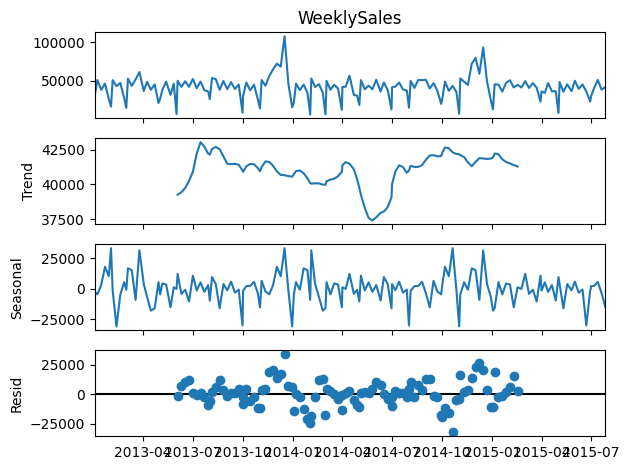

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

store_id = 11
store_series = df[df['Store'] == store_id].set_index('WeekStartDate')['WeeklySales']

decomposition = seasonal_decompose(store_series, model='additive', period=52)  # 52 weeks/year
decomposition.plot()
plt.tight_layout()
plt.show()

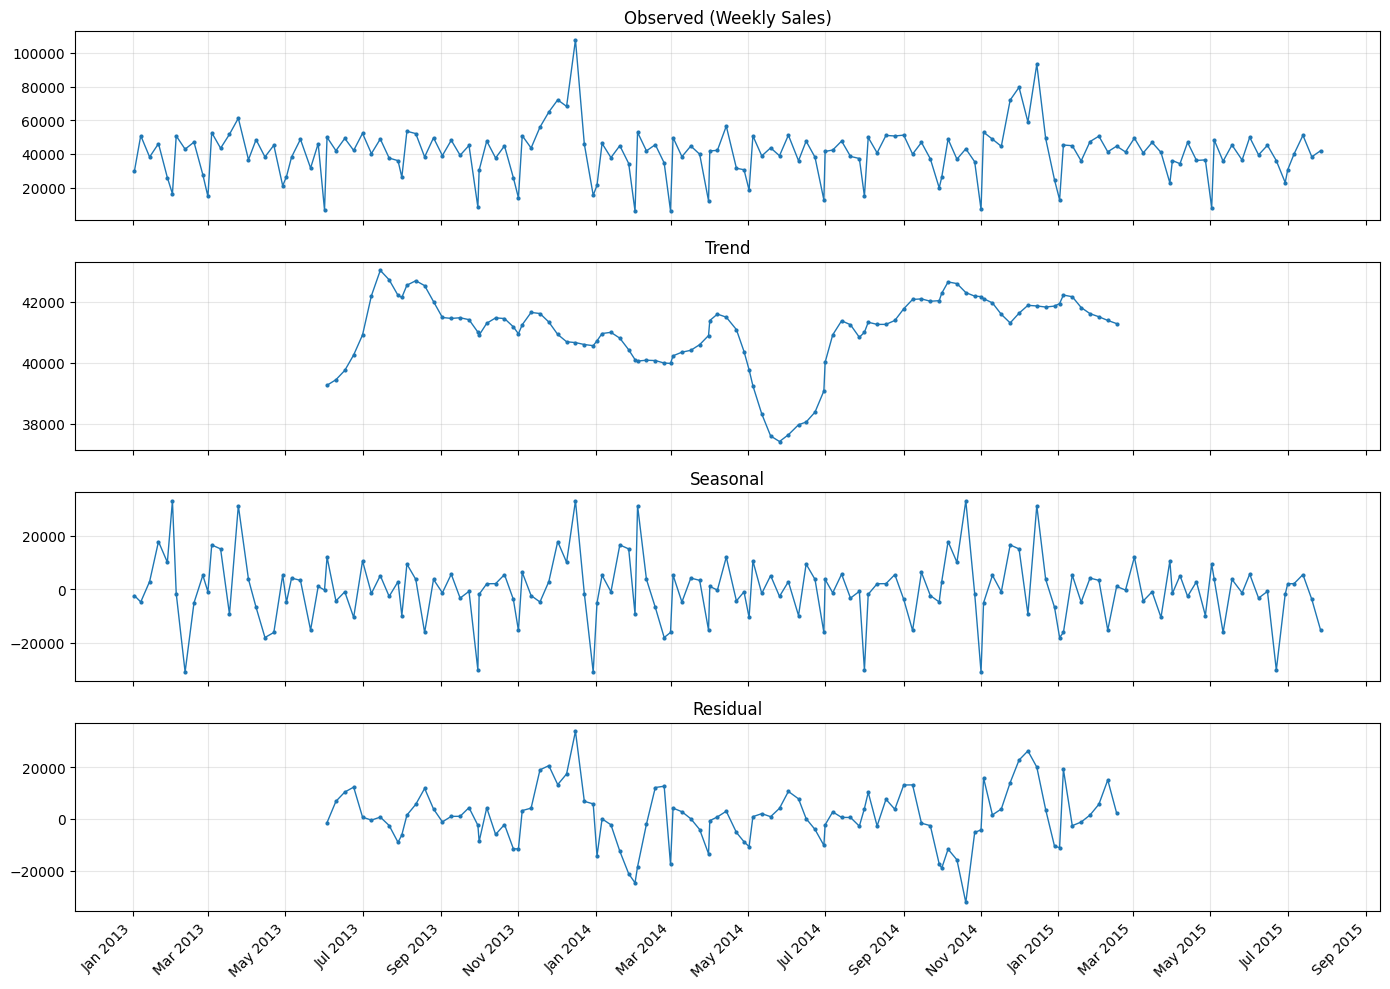

In [ ]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

components = [
    (decomposition.observed, 'Observed (Weekly Sales)'),
    (decomposition.trend, 'Trend'),
    (decomposition.seasonal, 'Seasonal'),
    (decomposition.resid, 'Residual')
]

for ax, (data, title) in zip(axes, components):
    ax.plot(data.index, data.values, marker='o', markersize=2, linewidth=1)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

train = store_series.iloc[:-8]
test = store_series.iloc[-8:]

model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,52))
fit = model.fit(disp=False)

forecast = fit.forecast(steps=8)

mape = mean_absolute_percentage_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"MAPE: {mape:.3f}, RMSE: {rmse:.1f}")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


MAPE: 0.119, RMSE: 4733.1


In [ ]:
store_series = store_series.asfreq('W-MON')  # forces strict weekly frequency, Monday-start
print(store_series.isna().sum())  # check how many weeks got created as gaps

0


In [ ]:
store_series = store_series.interpolate()

In [ ]:
train = store_series.iloc[:-8]
test = store_series.iloc[-8:]

model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,52))
fit = model.fit(disp=False)

forecast = fit.forecast(steps=8)

mape = mean_absolute_percentage_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"MAPE: {mape:.3f}, RMSE: {rmse:.1f}")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


MAPE: 0.119, RMSE: 4733.1


Store 85: 134 weeks, 0 interpolated gaps


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


Store 85 -> MAPE: 0.193, RMSE: 7344.7


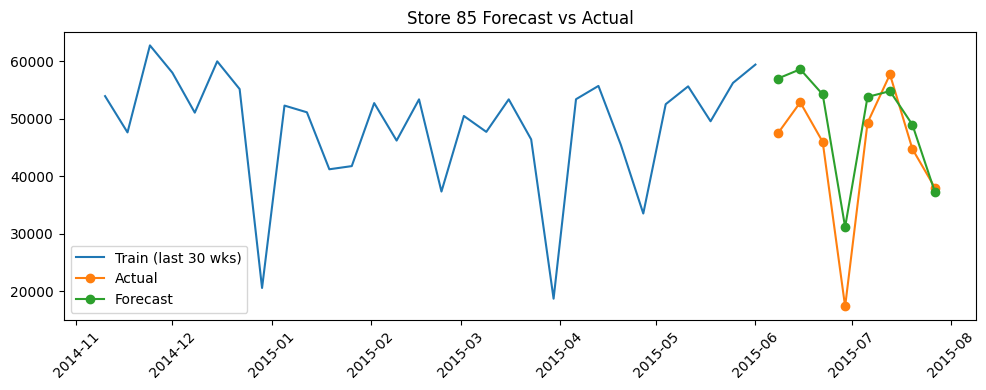

Store 262: 134 weeks, 0 interpolated gaps


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


Store 262 -> MAPE: 0.163, RMSE: 16132.6


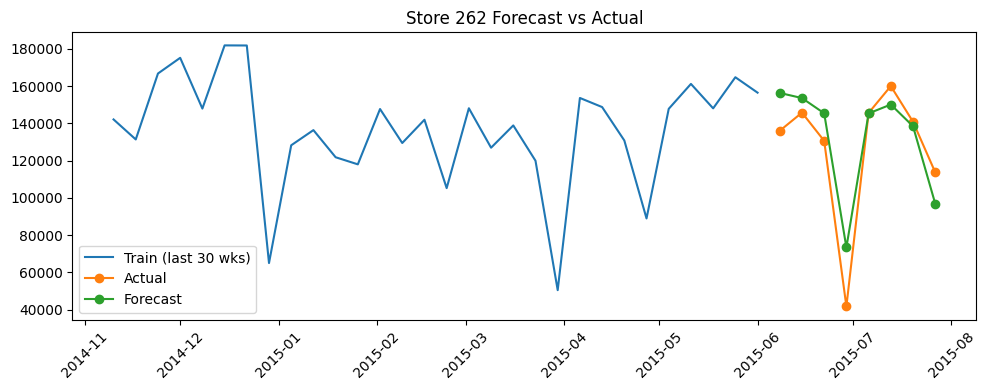

Store 700: 134 weeks, 0 interpolated gaps


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


Store 700 -> MAPE: 0.185, RMSE: 6078.0


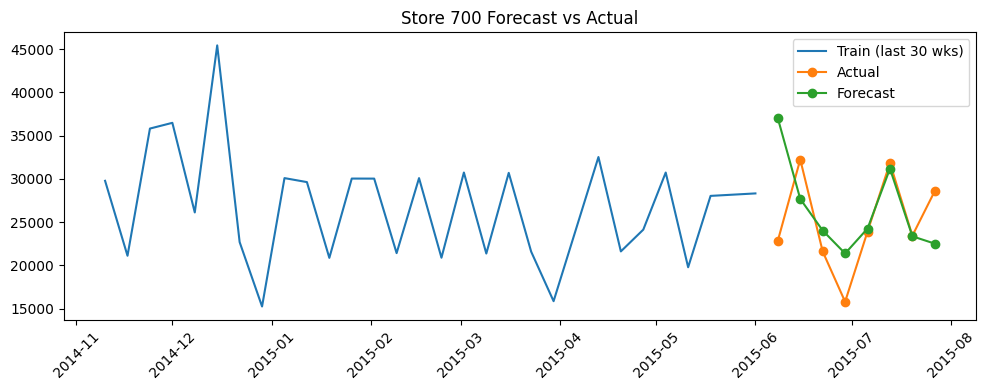

In [ ]:
def evaluate_store_forecast(store_id, df, test_weeks=8, plot=True):
    series = df[df['Store'] == store_id].set_index('WeekStartDate')['WeeklySales']
    series = series.asfreq('W-MON').interpolate()

    n_missing = series.isna().sum()
    print(f"Store {store_id}: {len(series)} weeks, {n_missing} interpolated gaps")

    train = series.iloc[:-test_weeks]
    test = series.iloc[-test_weeks:]

    model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,52))
    fit = model.fit(disp=False)
    forecast = fit.forecast(steps=test_weeks)

    mape = mean_absolute_percentage_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    print(f"Store {store_id} -> MAPE: {mape:.3f}, RMSE: {rmse:.1f}")

    if plot:
        plt.figure(figsize=(10,4))
        plt.plot(train.index[-30:], train.values[-30:], label='Train (last 30 wks)')
        plt.plot(test.index, test.values, label='Actual', marker='o')
        plt.plot(test.index, forecast, label='Forecast', marker='o')
        plt.legend()
        plt.title(f'Store {store_id} Forecast vs Actual')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    return mape, rmse

# Try a few different stores
for sid in [85, 262, 700]:   # pick a few store IDs that actually exist in your data
    evaluate_store_forecast(sid, df)

In [ ]:
import time

start = time.time()
evaluate_store_forecast(85, df, plot=False)
elapsed = time.time() - start
print(f"One store took {elapsed:.2f} seconds")
print(f"Estimated total for 1,115 stores: {elapsed * 1115 / 60:.1f} minutes")

Store 85: 134 weeks, 0 interpolated gaps


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/sarimax.py:1022: EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  self._conditional_sum_squares(


Store 85 -> MAPE: 0.193, RMSE: 7344.7
One store took 10.77 seconds
Estimated total for 1,115 stores: 200.2 minutes


In [ ]:
store_meta = df[['Store', 'StoreType', 'Assortment']].drop_duplicates()

sample_stores = (
    store_meta.groupby(['StoreType', 'Assortment'], group_keys=False)
    .apply(lambda x: x.sample(frac=150/len(store_meta), random_state=42))
)['Store'].tolist()

print(f"Sampled {len(sample_stores)} stores")

Sampled 150 stores


/tmp/ipykernel_1541/1776119914.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=150/len(store_meta), random_state=42))


In [ ]:
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings('ignore')

def fit_one_store(store_id, df, test_weeks=8):
    series = df[df['Store'] == store_id].set_index('WeekStartDate')['WeeklySales']
    series = series.asfreq('W-MON').interpolate()

    if len(series) < 60:
        return {'Store': store_id, 'MAPE': None, 'RMSE': None, 'note': 'insufficient history'}

    train = series.iloc[:-test_weeks]
    test = series.iloc[-test_weeks:]

    try:
        model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,52))
        fit = model.fit(disp=False)
        forecast = fit.forecast(steps=test_weeks)

        mape = mean_absolute_percentage_error(test, forecast)
        rmse = np.sqrt(mean_squared_error(test, forecast))
        return {'Store': store_id, 'MAPE': mape, 'RMSE': rmse, 'note': 'ok'}
    except Exception as e:
        return {'Store': store_id, 'MAPE': None, 'RMSE': None, 'note': str(e)}

results = Parallel(n_jobs=2)(  # Colab free tier = 2 vCPUs
    delayed(fit_one_store)(sid, df) for sid in sample_stores
)

results_df = pd.DataFrame(results)
print(results_df['note'].value_counts())
print(results_df[['MAPE', 'RMSE']].describe())

note
ok    150
Name: count, dtype: int64
             MAPE          RMSE
count  150.000000    150.000000
mean     0.176755   6525.515826
std      0.052243   2413.574247
min      0.076413   2545.154953
25%      0.141649   4733.764803
50%      0.165601   6111.838199
75%      0.213832   7673.618465
max      0.457426  15325.277456


In [ ]:
results_df.to_csv('sarima_results_per_store.csv', index=False)

In [ ]:
results_full = results_df.merge(store_meta, on='Store', how='left')
results_full.to_csv('sarima_results_with_metadata.csv', index=False)
results_full.groupby('StoreType')['MAPE'].mean()

,MAPE
StoreType,
a,0.160196
b,0.179817
c,0.179781
d,0.203874


In [ ]:
df['IsPromoWeek'] = (df['PromoShare'] >= 0.5).astype(int)
df.groupby('IsPromoWeek')['WeeklySales'].agg(['mean', 'std', 'count'])

,mean,std,count
IsPromoWeek,,,
0,29074.165294,15030.692471,79755
1,40797.879914,18375.473083,87004


In [ ]:
from scipy import stats

promo_sales = df[df['IsPromoWeek'] == 1]['WeeklySales']
non_promo_sales = df[df['IsPromoWeek'] == 0]['WeeklySales']

t_stat, p_value = stats.ttest_ind(promo_sales, non_promo_sales, equal_var=False)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_value:.5f}")

t-statistic: 143.082, p-value: 0.00000


In [ ]:
monthly_effect = df.groupby(['Mo', 'IsPromoWeek'])['WeeklySales'].mean().unstack()
monthly_effect.columns = ['NonPromo', 'Promo']
monthly_effect['Lift'] = monthly_effect['Promo'] - monthly_effect['NonPromo']
monthly_effect['LiftPct'] = (monthly_effect['Lift'] / monthly_effect['NonPromo']) * 100
print(monthly_effect)

        NonPromo         Promo          Lift     LiftPct
Mo                                                      
1   25116.362133  44099.970819  18983.608686   75.582636
2   25934.854594  44533.459625  18598.605031   71.712779
3   27151.974241  38718.859199  11566.884958   42.600530
4   31805.385999  36277.056327   4471.670328   14.059475
5   29388.815688  38206.061670   8817.245982   30.002046
6   30406.359427  38193.278652   7786.919225   25.609509
7   34883.872347  39549.164413   4665.292065   13.373779
8   34389.225971  36005.793578   1616.567607    4.700797
9   27286.977086  39712.017331  12425.040245   45.534689
10  28949.227063  39906.820477  10957.593414   37.851074
11  27360.903882  47193.133598  19832.229716   72.483825
12  30170.277715  60450.059326  30279.781612  100.362953


In [ ]:
pooled_std = np.sqrt((promo_sales.std()**2 + non_promo_sales.std()**2) / 2)
cohens_d = (promo_sales.mean() - non_promo_sales.mean()) / pooled_std
print(f"Cohen's d: {cohens_d:.3f}")

Cohen's d: 0.698


In [ ]:
holiday_sales = df[df['HadStateHoliday'] == 1]['WeeklySales']
non_holiday_sales = df[df['HadStateHoliday'] == 0]['WeeklySales']
t_stat2, p_value2 = stats.ttest_ind(holiday_sales, non_holiday_sales, equal_var=False)
print(f"State holiday effect -> t: {t_stat2:.3f}, p: {p_value2:.5f}")
print(f"Mean sales: holiday={holiday_sales.mean():.0f}, non-holiday={non_holiday_sales.mean():.0f}")

State holiday effect -> t: 17.185, p: 0.00000
Mean sales: holiday=50479, non-holiday=35110


In [ ]:
summary_stats = {
    'promo_t_stat': t_stat, 'promo_p_value': p_value, 'promo_cohens_d': cohens_d,
    'holiday_t_stat': t_stat2, 'holiday_p_value': p_value2,
    'promo_mean_sales': promo_sales.mean(), 'nonpromo_mean_sales': non_promo_sales.mean(),
    'holiday_mean_sales': holiday_sales.mean(), 'nonholiday_mean_sales': non_holiday_sales.mean()
}
pd.DataFrame([summary_stats]).to_csv('hypothesis_test_summary.csv', index=False)
monthly_effect.to_csv('monthly_promo_lift.csv')

In [ ]:
from joblib import Parallel, delayed
import warnings
def fit_one_store_with_forecast(store_id, df, test_weeks=8):
    series = df[df['Store'] == store_id].set_index('WeekStartDate')['WeeklySales']
    series = series.asfreq('W-MON').interpolate()

    if len(series) < 60:
        return None

    train = series.iloc[:-test_weeks]
    test = series.iloc[-test_weeks:]

    try:
        model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,52))
        fit = model.fit(disp=False)
        forecast = fit.forecast(steps=test_weeks)

        out = pd.DataFrame({
            'Store': store_id,
            'WeekStartDate': test.index,
            'ActualSales': test.values,
            'ForecastedSales': forecast.values
        })
        return out
    except Exception:
        return None

forecast_results = Parallel(n_jobs=2)(
    delayed(fit_one_store_with_forecast)(sid, df) for sid in sample_stores
)

forecast_df = pd.concat([r for r in forecast_results if r is not None], ignore_index=True)
forecast_df.to_csv('forecast_vs_actual.csv', index=False)
print(forecast_df.shape)
forecast_df.head()

(1200, 4)


,Store,WeekStartDate,ActualSales,ForecastedSales
0,798,2015-06-08,36477.0,51785.992596
1,798,2015-06-15,51126.0,53209.102037
2,798,2015-06-22,33725.0,41602.073667
3,798,2015-06-29,24676.0,35700.559646
4,798,2015-07-06,39551.0,43127.189099
